In [8]:
# ==========================================================
# Credit Card Fraud Detection - Exploratory Data Analysis
# Research: Hybrid Cloud–Edge Fraud Detection Framework
# ==========================================================

# Import required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Display all columns
pd.set_option('display.max_columns', None)

# Plot style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

print("=" * 50)
print("✅ All required libraries loaded successfully!")
print("=" * 50)

Matplotlib is building the font cache; this may take a moment.


✅ All required libraries loaded successfully!


In [2]:
# Load Credit Card Fraud Detection dataset
df = pd.read_csv("../data/raw/creditcard/creditcard.csv")

# Display first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# ==========================================================
# Dataset Shape
# ==========================================================

print("Number of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows    : 284807
Number of Columns : 31


In [5]:
# ==========================================================
# Dataset Information
# ==========================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
# ==========================================================
# Statistical Summary
# ==========================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [7]:
# ==========================================================
# Missing Values
# ==========================================================

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print("✅ No missing values found.")
else:
    print(missing_values)

✅ No missing values found.


In [7]:
# ==========================================================
# Duplicate Records
# ==========================================================

duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 1081


In [8]:
# ==========================================================
# Class Distribution
# ==========================================================

class_counts = df['Class'].value_counts()

print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


In [9]:
# ==========================================================
# Fraud Percentage
# ==========================================================

fraud_percentage = df['Class'].value_counts(normalize=True) * 100

print(fraud_percentage)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24424\1031758245.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Class', palette='Set2')


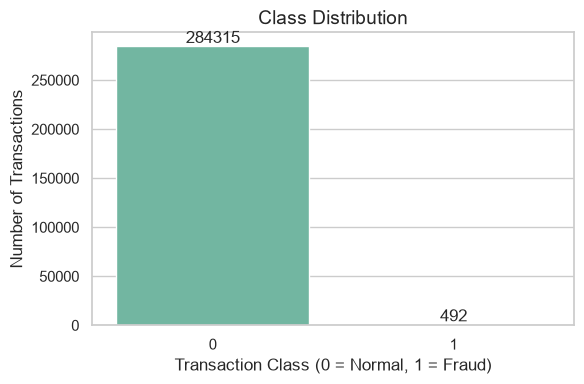

In [9]:
# ==========================================================
# Class Distribution
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='Class', palette='Set2')

plt.title("Class Distribution", fontsize=14)
plt.xlabel("Transaction Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

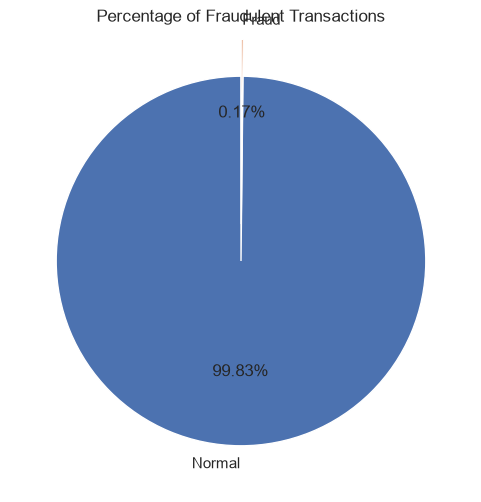

In [11]:
# ==========================================================
# Fraud Percentage
# ==========================================================

fraud_counts = df['Class'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    fraud_counts,
    labels=['Normal','Fraud'],
    autopct='%1.2f%%',
    startangle=90,
    explode=(0,0.2)
)

plt.title("Percentage of Fraudulent Transactions")

plt.show()

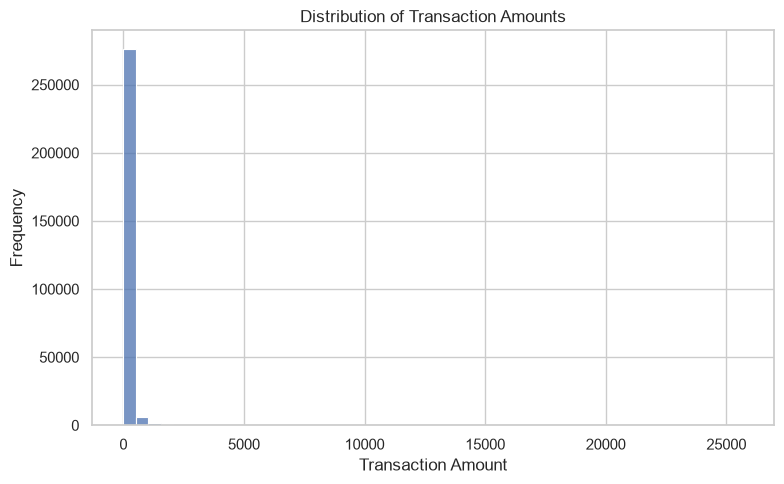

In [12]:
# ==========================================================
# Transaction Amount Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(df['Amount'], bins=50)

plt.title("Distribution of Transaction Amounts")

plt.xlabel("Transaction Amount")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

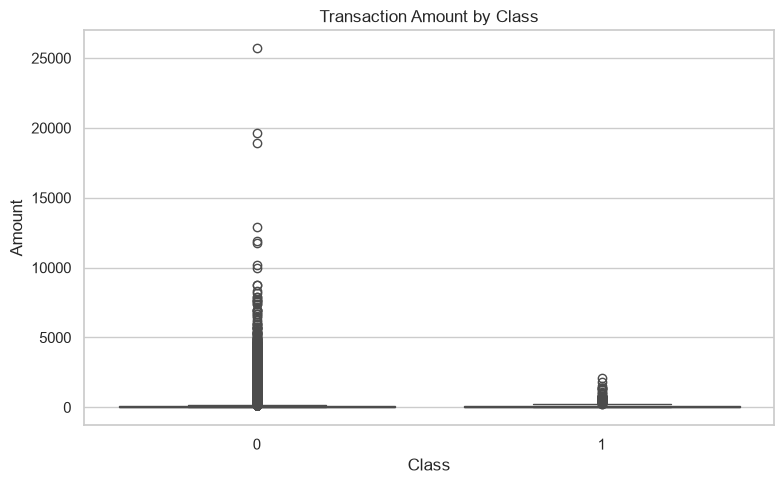

In [13]:
# ==========================================================
# Transaction Amount by Class
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Class', y='Amount')

plt.title("Transaction Amount by Class")

plt.xlabel("Class")

plt.ylabel("Amount")

plt.tight_layout()

plt.show()

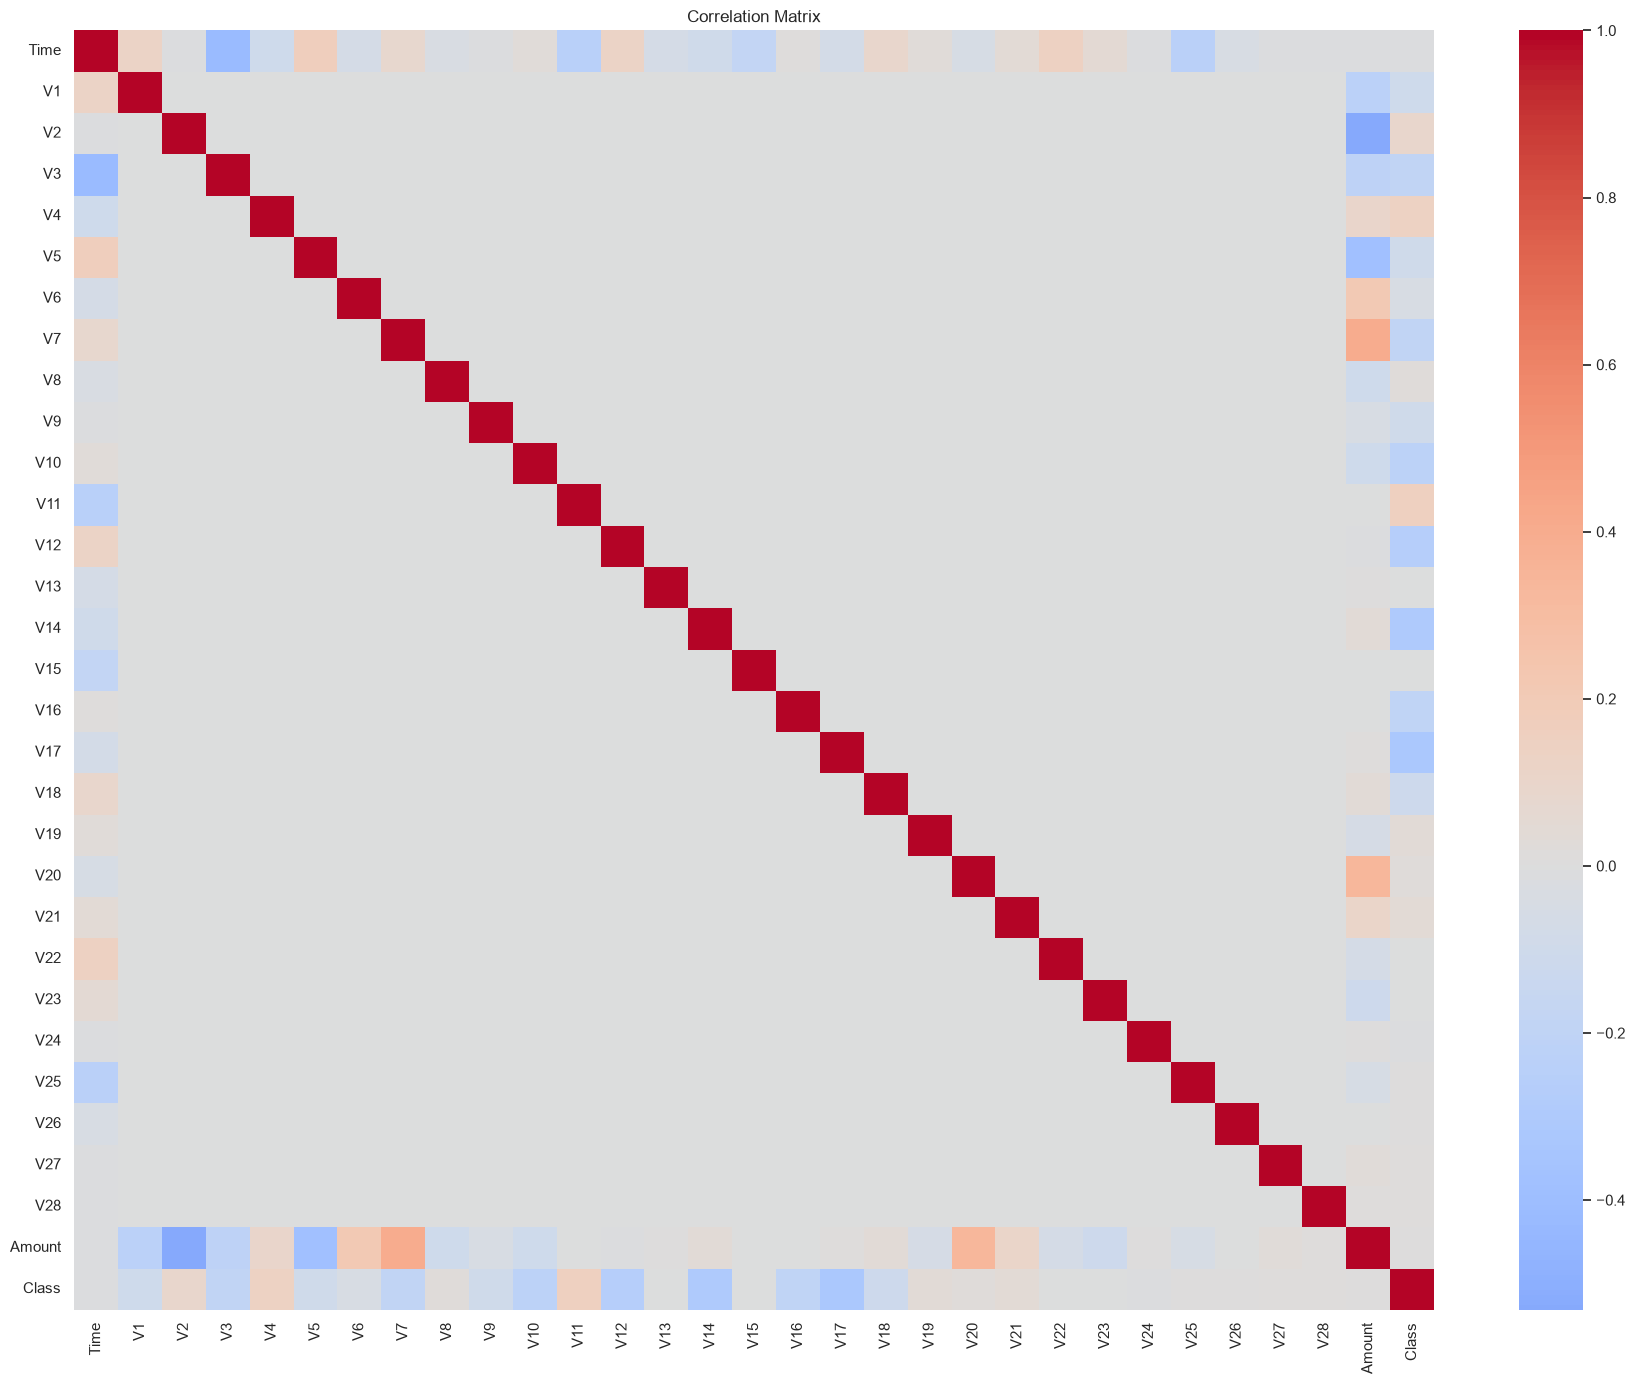

In [14]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(18,14))

corr = df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [15]:
# ==========================================================
# Top Correlated Features with Fraud
# ==========================================================

corr_with_class = df.corr()['Class'].sort_values(ascending=False)

print(corr_with_class.head(10))

print("\n")

print(corr_with_class.tail(10))

Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64


V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64
